In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Tugas BK1: [Fetal Health Dataset]
- **Nama:** [Rozaq Leksono]
- **Nim:** [A11.2021.13700]
- **Link Yt:** [https://youtu.be/tgqKrlu2iFQ]
- **Link Yt2:** [https://youtu.be/2vlhomg-dxo?si=PYZhNQrydqEo51hI]

## Informasi data
## Kardiotokografi (CTG) dalam Pemantauan Kehamilan

Kardiotokografi (CTG) digunakan selama kehamilan untuk memantau denyut jantung janin dan kontraksi rahim. Tujuan utamanya adalah:

1. Memantau kesejahteraan janin
2. Memungkinkan deteksi dini gangguan pada janin

Interpretasi CTG membantu menentukan apakah kehamilan berisiko tinggi atau rendah. Sebuah CTG abnormal dapat mengindikasikan perlunya pemeriksaan lebih lanjut dan potensi intervensi medis.

### Cara Kerja Peralatan CTG

Peralatan CTG merupakan opsi sederhana dan terjangkau untuk menilai kesehatan janin. Cara kerjanya adalah:
- Mengirimkan pulsa ultrasound
- Membaca respon yang diterima
- Menghasilkan informasi tentang:
  * Laju denyut jantung janin (FHR)
  * Gerakan janin
  * Kontraksi rahim
  * Dan parameter kesehatan lainnya

### Dataset Penelitian

Dataset ini berisi:
- 2126 catatan fitur yang diekstrak dari pemeriksaan Kardiotokogram
- Diklasifikasikan oleh ahli kebidanan ke dalam 3 kelas:
  1. Normal
  2. Dicurigai
  3. Patologis

Klasifikasi ini memungkinkan tenaga kesehatan untuk mengambil tindakan yang tepat guna mencegah kematian ibu dan bayi.

## Fitur-Fitur Dataset Kardiotokografi

### Fitur Utama:

1. **Nilai Dasar (Baseline Value)**
   - Laju Denyut Jantung Janin Dasar (detak per menit)

2. **Akselerasi**
   - Jumlah akselerasi per detik

3. **Gerakan Janin**
   - Jumlah gerakan janin per detik

4. **Kontraksi Rahim**
   - Jumlah kontraksi rahim per detik

5. **Deselerasi Ringan**
   - Jumlah deselerasi ringan per detik

6. **Deselerasi Berat**
   - Jumlah deselerasi berat per detik

7. **Deselerasi Berkepanjangan**
   - Jumlah deselerasi berkepanjangan per detik

### Fitur Variabilitas:

8. **Variabilitas Jangka Pendek Abnormal**
   - Persentase waktu dengan variabilitas jangka pendek abnormal

9. **Nilai Rata-Rata Variabilitas Jangka Pendek**
   - Nilai rata-rata variabilitas jangka pendek

10. **Variabilitas Jangka Panjang Abnormal**
    - Persentase waktu dengan variabilitas jangka panjang abnormal

11. **Nilai Rata-Rata Variabilitas Jangka Panjang**
    - Nilai rata-rata variabilitas jangka panjang

### Fitur Histogram:

12. **Lebar Histogram**
    - Lebar histogram Laju Denyut Jantung (FHR)

13. **Minimum Histogram**
    - Frekuensi rendah minimum histogram FHR

14. **Maksimum Histogram**
    - Frekuensi tinggi maksimum histogram FHR

15. **Jumlah Puncak Histogram**
    - Jumlah puncak dalam histogram

16. **Jumlah Nol Histogram**
    - Jumlah nol dalam histogram

17. **Modus Histogram**
    - Modus histogram

18. **Rata-Rata Histogram**
    - Rata-rata histogram

19. **Median Histogram**
    - Median histogram

20. **Varians Histogram**
    - Varians histogram

21. **Kecenderungan Histogram**
    - Kecenderungan histogram

### Variabel Target:

**Kesehatan Janin**
- 1: Normal
- 2: Dicurigai
- 3: Patologis

Setiap fitur memberikan informasi detail tentang kondisi janin, membantu tenaga medis dalam menilai kesehatan dan potensi risiko selama kehamilan.

# 1.Mengumpulkan data

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import data

In [ ]:
df = pd.read_csv("/content/fetal_health.csv", delimiter=",")
#data.head()

In [ ]:
# Untuk mengetahui ukuran dataset, yaitu jumlah baris dan kolom
df.shape

(2126, 22)

# 2.Menelaah data

In [ ]:
# Untuk menampilkan 5 baris pertama
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,NaN,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [ ]:
# Deskripsi statistik dataset, seperti nilai rata-rata (mean), standar deviasi (std), nilai minimum (min),
# kuartil (25%, 50%, 75%), dan nilai maksimum (max).
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,1914.000000,2126.000000,2126.000000,1914.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,1914.000000,2126.000000,2126.000000,1914.000000,1914.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004372,0.001889,0.000003,0.000158,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.477011,134.610536,138.090310,19.020899,0.319749,1.304327
std,9.840844,0.003866,0.046666,0.002953,0.002960,0.000057,0.000592,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.434563,15.593596,14.466589,29.628676,0.610208,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.005000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [ ]:
# Menampilkan informasi dasar tentang dataset
# termasuk jumlah baris dan kolom, nama kolom, jumlah nilai non-null di setiap kolom, tipe data (data type) setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    1914 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                1914 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

**Insight:**
- Dari pengecekan di atas Bisa dilihat bahwa pada kolom pertama (0), yaitu baseline value, penggunaan spasi dalam nama kolom dapat menyulitkan manipulasi data. Hal ini karena nama kolom dengan spasi harus selalu diakses menggunakan tanda kurung siku ([]) seperti df['baseline value'], yang kurang praktis dan rentan terhadap kesalahan.

# 3.Memvalidasi data

In [ ]:
# Menampilkan banyaknya missing values pada data
missing_df = df.isnull().sum().to_frame().rename(columns={0: "Total No. of Missing Values"})
print(missing_df)

                                                    Total No. of Missing Values
baseline value                                                                0
accelerations                                                                 0
fetal_movement                                                                0
uterine_contractions                                                        212
light_decelerations                                                           0
severe_decelerations                                                          0
prolongued_decelerations                                                    212
abnormal_short_term_variability                                               0
mean_value_of_short_term_variability                                          0
percentage_of_time_with_abnormal_long_term_vari...                            0
mean_value_of_long_term_variability                                           0
histogram_width                         

In [ ]:
# Menampilkan banyaknya duplicate pada data
duplicate_count = df.duplicated().sum()  # Calculate the number of duplicates
duplicate_df = pd.DataFrame([duplicate_count], columns=["Total No. of Duplicate Values"])  # Create DataFrame from the count
print(duplicate_df)

   Total No. of Duplicate Values
0                              5


**Insight:**
- Dari pengecekan di atas ditemukan missing value dan duplicate sebanyak 5 kolom

# 4.Menentukan object data

In [ ]:
# Menampilkan nilai-nilai unik yang ada pada setiap kolom dalam dataset
for col in df:
    print(f"{col} has {df[col].unique()} values")

baseline value has [120. 132. 133. 134. 122. 151. 150. 131. 130. 129. 128. 124. 115. 114.
 116. 158. 156. 148. 149. 146. 144. 142. 136. 141. 138. 140. 154. 145.
 139. 125. 123. 159. 143. 119. 121. 127. 126. 118. 135. 137. 147. 157.
 117. 152. 112. 106. 110. 160.] values
accelerations has [0.    0.006 0.003 0.007 0.001 0.005 0.009 0.002 0.008 0.004 0.01  0.015
 0.013 0.014 0.011 0.017 0.012 0.016 0.019 0.018] values
fetal_movement has [0.    0.072 0.222 0.408 0.38  0.441 0.383 0.451 0.469 0.34  0.425 0.334
 0.135 0.099 0.108 0.112 0.089 0.103 0.085 0.109 0.079 0.065 0.055 0.058
 0.047 0.038 0.012 0.018 0.02  0.005 0.003 0.006 0.001 0.004 0.009 0.01
 0.002 0.008 0.007 0.028 0.026 0.107 0.013 0.016 0.029 0.05  0.053 0.011
 0.015 0.022 0.021 0.017 0.019 0.025 0.014 0.024 0.023 0.035 0.054 0.03
 0.048 0.088 0.043 0.052 0.091 0.033 0.092 0.084 0.115 0.041 0.04  0.027
 0.031 0.063 0.06  0.071 0.306 0.298 0.139 0.189 0.157 0.235 0.36  0.455
 0.443 0.47  0.477 0.446 0.481 0.369 0.335 0.43  0.34

**Insight:**
- Karena semua kolom dalam data bertipe numerik, maka tidak perlu membagi data menjadi 2 bagian

# 5.Membersihkan data

##Mengganti nama kolom

In [ ]:
# Mengganti nama kolom 'baseline value' menjadi 'baseline_value'
df.rename(columns={'baseline value': 'baseline_value'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline_value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    1914 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                1914 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

##Handling duplikat

In [ ]:
#hapus duplikat
df.drop_duplicates(inplace = True)

##Handing missing value


In [ ]:
# Karena diketahui ada data yang jumlahnya tidak selalu sama, maka kita bisa mengisi nilai yang hilang dengan rata-rata (bisa juga dengan median, modus, dll)
# Mengisi nilai yang hilang dengan rata-rata
df.fillna(df.mean(), inplace=True)


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

,0
baseline_value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2121 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline_value                                          2121 non-null   float64
 1   accelerations                                           2121 non-null   float64
 2   fetal_movement                                          2121 non-null   float64
 3   uterine_contractions                                    2121 non-null   float64
 4   light_decelerations                                     2121 non-null   float64
 5   severe_decelerations                                    2121 non-null   float64
 6   prolongued_decelerations                                2121 non-null   float64
 7   abnormal_short_term_variability                         2121 non-null   float64
 8   mean_value_of_short_term_variability       

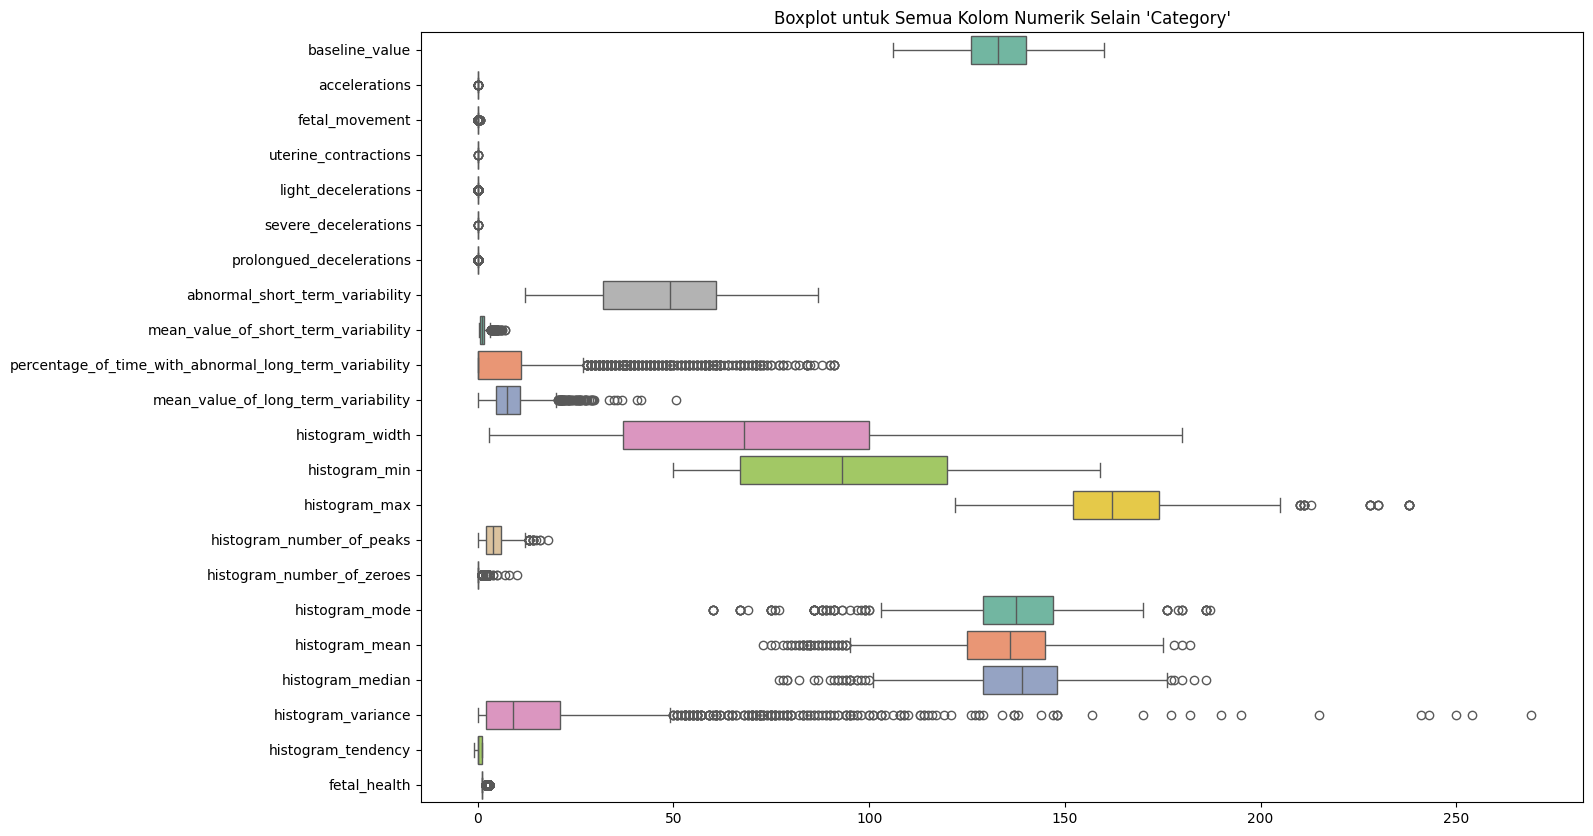

In [ ]:
# Pilih hanya kolom numerik selain kolom Target ('Category' dalam kasus ini)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols[num_cols != 'Category']  # Menghapus kolom 'Category'

# Buat boxplot untuk setiap kolom numerik selain 'Category'
plt.figure(figsize=(15, 10)) # mengatur ukuran gambar
sns.boxplot(data=df[num_cols], orient='h', palette="Set2") # membuat boxplot horizontal dengan palet warna "Set2"

plt.title("Boxplot untuk Semua Kolom Numerik Selain 'Category'") # memberi judul pada plot
plt.show() # menampilkan plot

## Handling Outliers

bertujuan untuk mengidentifikasi dan memodifikasi atau menghapus nilai-nilai ekstrem dalam dataset yang secara signifikan menyimpang dari data lainnya

In [ ]:
data_iqr = df.copy() # Salin dataset asli

for col in df.select_dtypes(include=['float64']).columns:
    Q1 = df[col].quantile(0.25) # Kuartil pertama (25%)
    Q3 = df[col].quantile(0.75) # Kuartil ketiga (75%)
    IQR = Q3 - Q1 # Hitung IQR (Interquartile Range)
    lower_bound = Q1 - 1.5 * IQR # Tentukan batas bawah untuk outlier
    upper_bound = Q3 + 1.5 * IQR # Tentukan batas atas untuk outlier

    # Ganti outliers dengan batas bawah/atas
    data_iqr[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    print(f"Outliers pada kolom '{col}' telah ditangani menggunakan metode IQR.")

Outliers pada kolom 'baseline_value' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'accelerations' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'fetal_movement' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'uterine_contractions' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'light_decelerations' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'severe_decelerations' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'prolongued_decelerations' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'abnormal_short_term_variability' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'mean_value_of_short_term_variability' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'percentage_of_time_with_abnormal_long_term_variability' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'mean_value_of_long_term_variability' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'histog

Dengan mengganti outlier dengan batas bawah atau atas, kita mengurangi dampak outlier pada analisis data selanjutnya, seperti pemodelan atau visualisasi. Metode ini efektif untuk menangani outlier yang tidak disebabkan oleh kesalahan pengukuran atau kesalahan data lainnya. Jika outlier disebabkan oleh kesalahan, maka sebaiknya diperbaiki atau dihapus, bukan diganti dengan batas.

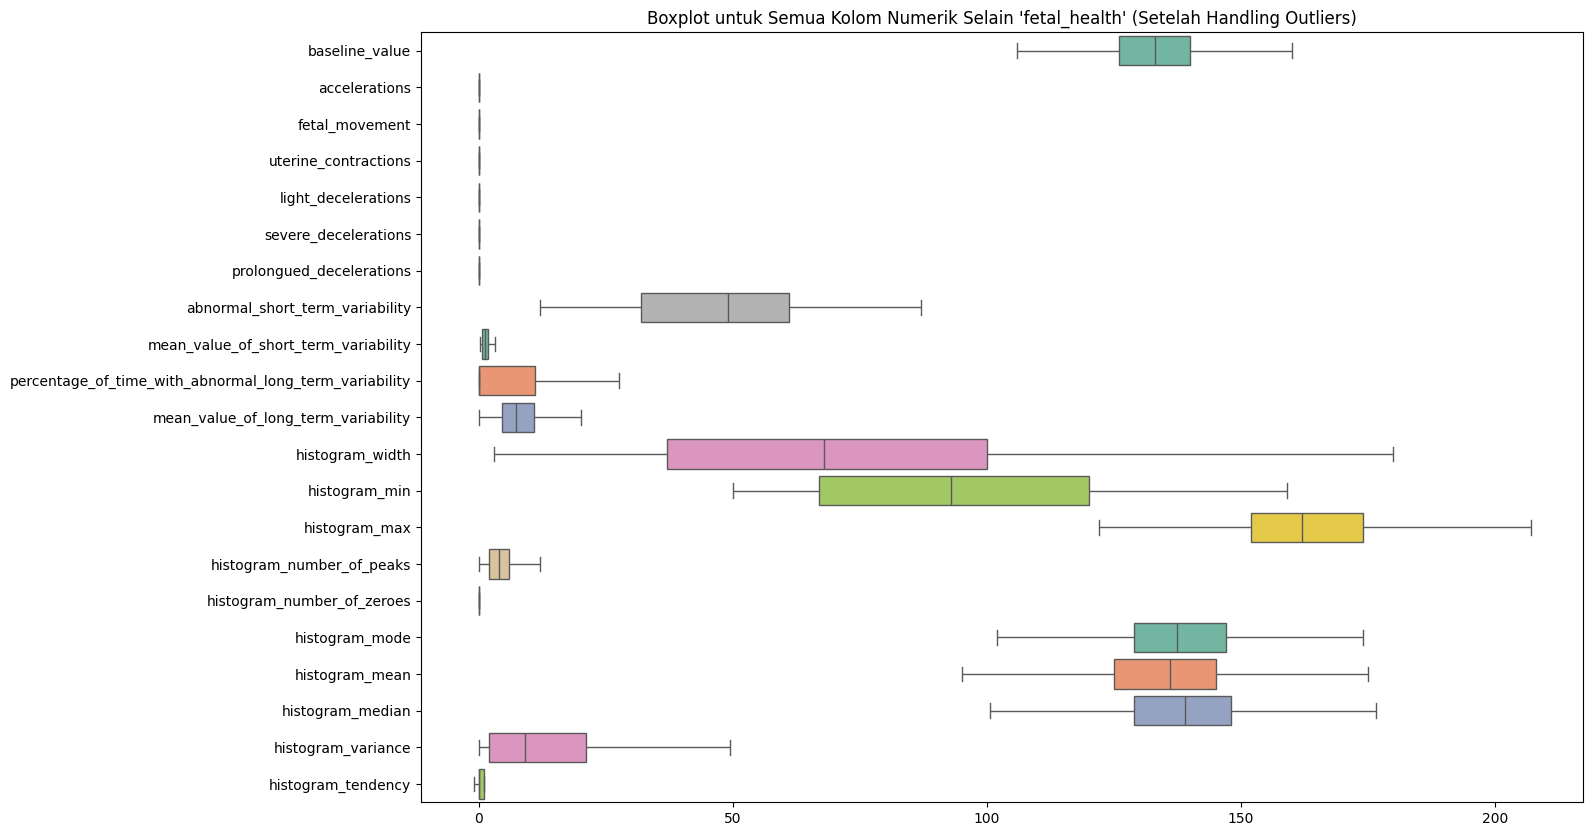

In [ ]:
# Pilih hanya kolom numerik selain kolom target
numerical_cols = data_iqr.select_dtypes(include=['float64']).columns

numerical_cols = numerical_cols[numerical_cols != 'fetal_health'] # Menghapus kolom 'fetal_health'

# Buat boxplot untuk setiap kolom numerik selain 'fetal_health'
plt.figure(figsize=(15, 10))

sns.boxplot(data=data_iqr[numerical_cols], orient='h', palette="Set2")
plt.title("Boxplot untuk Semua Kolom Numerik Selain 'fetal_health' (Setelah Handling Outliers)")
plt.show()

Menghapus outlier bukanlah keputusan yang mudah karena bisa jadi memberi pengaruh buruk pada analisis atau model. Meskipun terkadang menghapus outlier dapat menghasilkan statistik atau model yang lebih baik, tetap saja ada risiko overfitting, yaitu model terlalu terfokus pada data yang tersisa dan tidak dapat bekerja baik pada data baru.

# 6.Merekontruksi data

In [ ]:
# Import Library yang dibutuhkan untuk handling imbalance
# Menggunakan metode oversampling
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
# Memisahkan kolom feature (x) dan kolom target (y)
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

 Dengan memisahkan fitur dan target, kita mempersiapkan data untuk proses pelatihan dan evaluasi model.

 membagi data menjadi data latih dan data uji, serta melakukan oversampling

In [ ]:
# Split data untuk training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Oversampling menggunakan RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_over, y_over = oversample.fit_resample(X_train, y_train)

# Tampilkan distribusi kelas setelah diseimbangkan
print("Distribusi kelas setelah oversampling:", Counter(y_over))

Distribusi kelas setelah oversampling: Counter({3.0: 1155, 1.0: 1155, 2.0: 1155})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


<ipython-input-80-4738685436de>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


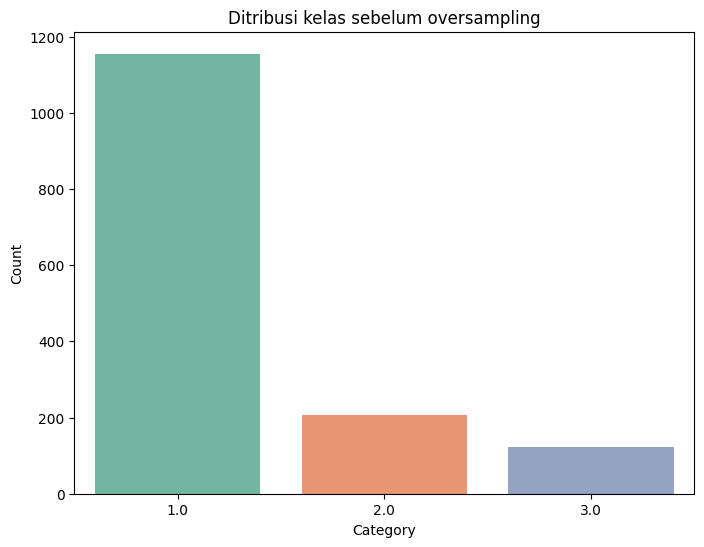

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
<ipython-input-80-4738685436de>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_over, palette="Set2")


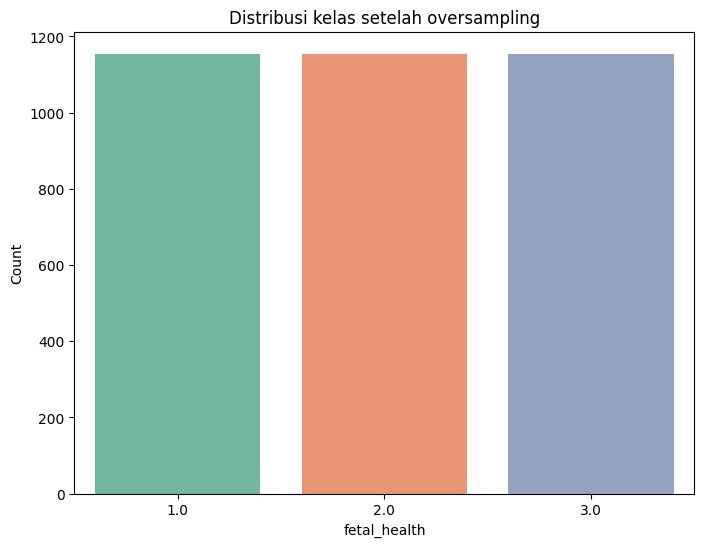

In [ ]:
# Visualisasi distribusi kelas sebelum handling imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette="Set2")
plt.title("Ditribusi kelas sebelum oversampling")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Oversampling menggunakan RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_over, y_over = oversample.fit_resample(X_train, y_train)

# Visualisasi distribusi kelas setelah oversampling
plt.figure(figsize=(8, 6))
sns.countplot(x=y_over, palette="Set2")
plt.title("Distribusi kelas setelah oversampling")
plt.xlabel("fetal_health")
plt.ylabel("Count")
plt.show()

In [ ]:
oversampled_df = pd.DataFrame(X_over, columns=data_iqr.drop("fetal_health", axis=1).columns)
oversampled_df['fetal_health'] = y_over

oversampled_df

,baseline_value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,125.0,0.000,0.009,0.00000,0.000,0.0,0.000000,68.0,0.3,75.0,...,120.0,128.0,0.0,0.0,125.0,125.0,126.0,0.000000,0.000000,3.0
1,143.0,0.006,0.000,0.00800,0.002,0.0,0.000000,28.0,1.4,0.0,...,102.0,182.0,3.0,0.0,155.0,152.0,154.0,23.000000,0.000000,1.0
2,130.0,0.000,0.000,0.00438,0.007,0.0,0.000000,37.0,1.8,0.0,...,58.0,148.0,4.0,1.0,127.0,121.0,126.0,21.000000,1.000000,1.0
3,129.0,0.000,0.001,0.00438,0.008,0.0,0.000159,65.0,2.8,0.0,...,50.0,151.0,7.0,2.0,105.0,86.0,112.0,13.000000,0.319539,3.0
4,137.0,0.008,0.001,0.00500,0.003,0.0,0.000000,58.0,1.6,0.0,...,69.0,178.0,5.0,0.0,148.0,143.0,151.0,55.000000,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,133.0,0.000,0.000,0.00000,0.000,0.0,0.000000,73.0,0.2,88.0,...,131.0,139.0,1.0,0.0,133.0,134.0,135.0,0.000000,0.000000,3.0
3461,130.0,0.000,0.346,0.00000,0.000,0.0,0.003000,80.0,0.3,0.0,...,96.0,145.0,3.0,0.0,108.0,123.0,122.0,19.063384,0.319539,3.0
3462,123.0,0.000,0.000,0.00000,0.000,0.0,0.000000,73.0,0.3,91.0,...,120.0,129.0,2.0,0.0,123.0,124.0,125.0,0.000000,0.000000,3.0
3463,133.0,0.000,0.000,0.00000,0.000,0.0,0.000000,75.0,0.2,91.0,...,131.0,138.0,1.0,0.0,133.0,134.0,135.0,0.000000,0.000000,3.0


#7.Menentukan Label Data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Memisahkan kolom feature dan kolom target
X = oversampled_df.drop("fetal_health",axis=1).values
y = oversampled_df['fetal_health']

In [ ]:
# Split data dengan perbandingan data training dan data testing adalah 70 : 30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#8.Membangun Model

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

## Training Model

In [ ]:
# Nama Model
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)
svm = SVC(random_state=42)
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()

models = {
    "Naive Bayes": nb,
    "Random Forest": rf,
    "SVM": svm,
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "K-Nearest Neighbors": knn,

}

###Naive Bayes

In [ ]:
nb.fit(X_train, y_train)

nb_y_pred = nb.predict(X_test)
accuracy_nb = round(accuracy_score(y_test, nb_y_pred), 3)

print(confusion_matrix(y_test, nb_y_pred))

print(classification_report(y_test, nb_y_pred))

[[262  75  25]
 [ 36 286  19]
 [ 18  89 230]]
              precision    recall  f1-score   support

         1.0       0.83      0.72      0.77       362
         2.0       0.64      0.84      0.72       341
         3.0       0.84      0.68      0.75       337

    accuracy                           0.75      1040
   macro avg       0.77      0.75      0.75      1040
weighted avg       0.77      0.75      0.75      1040



###Random Forest

In [ ]:
rf.fit(X_train, y_train)

rf_y_pred = rf.predict(X_test)
accuracy_rf = round(accuracy_score(y_test, rf_y_pred), 3)

print(confusion_matrix(y_test, rf_y_pred))

print(classification_report(y_test, rf_y_pred))

[[350  10   2]
 [  1 340   0]
 [  0   0 337]]
              precision    recall  f1-score   support

         1.0       1.00      0.97      0.98       362
         2.0       0.97      1.00      0.98       341
         3.0       0.99      1.00      1.00       337

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040



###SVM

In [ ]:
svm.fit(X_train, y_train)

svm_y_pred = svm.predict(X_test)
accuracy_svm = round(accuracy_score(y_test, svm_y_pred), 3)

print(confusion_matrix(y_test, svm_y_pred))

print(classification_report(y_test, svm_y_pred))

[[294  55  13]
 [ 41 284  16]
 [ 21  32 284]]
              precision    recall  f1-score   support

         1.0       0.83      0.81      0.82       362
         2.0       0.77      0.83      0.80       341
         3.0       0.91      0.84      0.87       337

    accuracy                           0.83      1040
   macro avg       0.83      0.83      0.83      1040
weighted avg       0.83      0.83      0.83      1040



###Logistic Regression

In [ ]:
lr.fit(X_train, y_train)

lr_y_pred = lr.predict(X_test)
accuracy_lr = round(accuracy_score(y_test, lr_y_pred), 3)

print(confusion_matrix(y_test, lr_y_pred))

print(classification_report(y_test, lr_y_pred))

[[296  54  12]
 [ 66 240  35]
 [ 17  29 291]]
              precision    recall  f1-score   support

         1.0       0.78      0.82      0.80       362
         2.0       0.74      0.70      0.72       341
         3.0       0.86      0.86      0.86       337

    accuracy                           0.80      1040
   macro avg       0.79      0.79      0.79      1040
weighted avg       0.79      0.80      0.79      1040



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


###Decision Tree

In [ ]:
dt.fit(X_train, y_train)

dt_y_pred = dt.predict(X_test)
accuracy_dt = round(accuracy_score(y_test, dt_y_pred), 3)

print(confusion_matrix(y_test, dt_y_pred))

print(classification_report(y_test, dt_y_pred))

[[334  24   4]
 [  1 340   0]
 [  0   0 337]]
              precision    recall  f1-score   support

         1.0       1.00      0.92      0.96       362
         2.0       0.93      1.00      0.96       341
         3.0       0.99      1.00      0.99       337

    accuracy                           0.97      1040
   macro avg       0.97      0.97      0.97      1040
weighted avg       0.97      0.97      0.97      1040



###K-Nearest Neighbors

In [ ]:
knn.fit(X_train, y_train)

knn_y_pred = knn.predict(X_test)
accuracy_knn = round(accuracy_score(y_test, knn_y_pred), 3)

print(confusion_matrix(y_test, knn_y_pred))

print(classification_report(y_test, knn_y_pred))

[[312  45   5]
 [  8 327   6]
 [  2   0 335]]
              precision    recall  f1-score   support

         1.0       0.97      0.86      0.91       362
         2.0       0.88      0.96      0.92       341
         3.0       0.97      0.99      0.98       337

    accuracy                           0.94      1040
   macro avg       0.94      0.94      0.94      1040
weighted avg       0.94      0.94      0.94      1040



#9.komparasi Model

<ipython-input-93-c2a6ffa7dd51>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


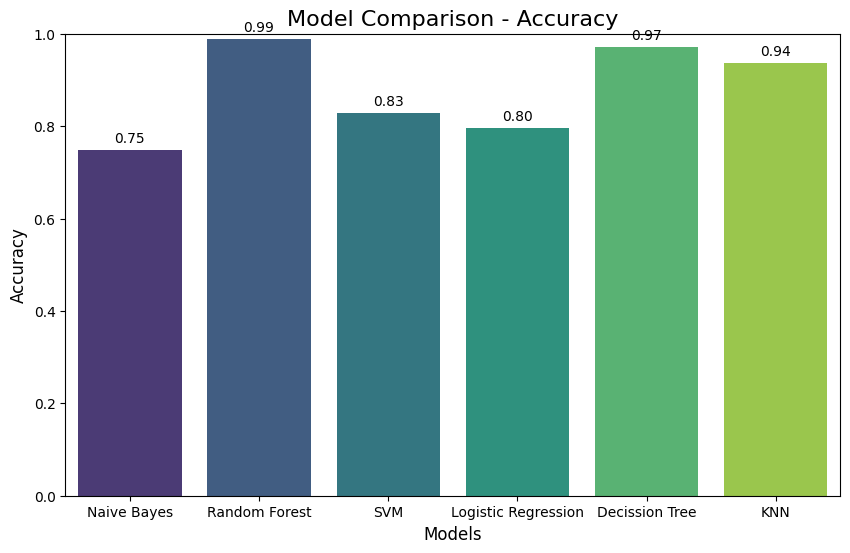

In [ ]:
models = ['Naive Bayes', 'Random Forest', 'SVM', 'Logistic Regression', 'Decission Tree', 'KNN']
accuracies = [
    accuracy_score(y_test, nb_y_pred),
    accuracy_score(y_test, rf_y_pred),
    accuracy_score(y_test, svm_y_pred),
    accuracy_score(y_test, lr_y_pred),
    accuracy_score(y_test, dt_y_pred),
    accuracy_score(y_test, knn_y_pred)
]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.title('Model Comparison - Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim(0, 1)
plt.show()

#10.Optimasi Model

Tidak perlu melakukan optimasi model karena model dengan akurasi tertinggi sudah mencapai 99%

In [ ]:
#df.to_csv("fetalHealth2.csv", index=False)